/tmp/ipykernel_18016/2455443661.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['bhk']=df2['size'].apply(lambda x: int(x.split(' ')[0]))


/workspaces/Real-Estate-Price-Prediction-Project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/workspaces/Real-Estate-Price-Prediction-Project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/workspaces/Real-Estate-Price-Prediction-Project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/workspaces/Real-Estate-Price-Prediction-Project/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


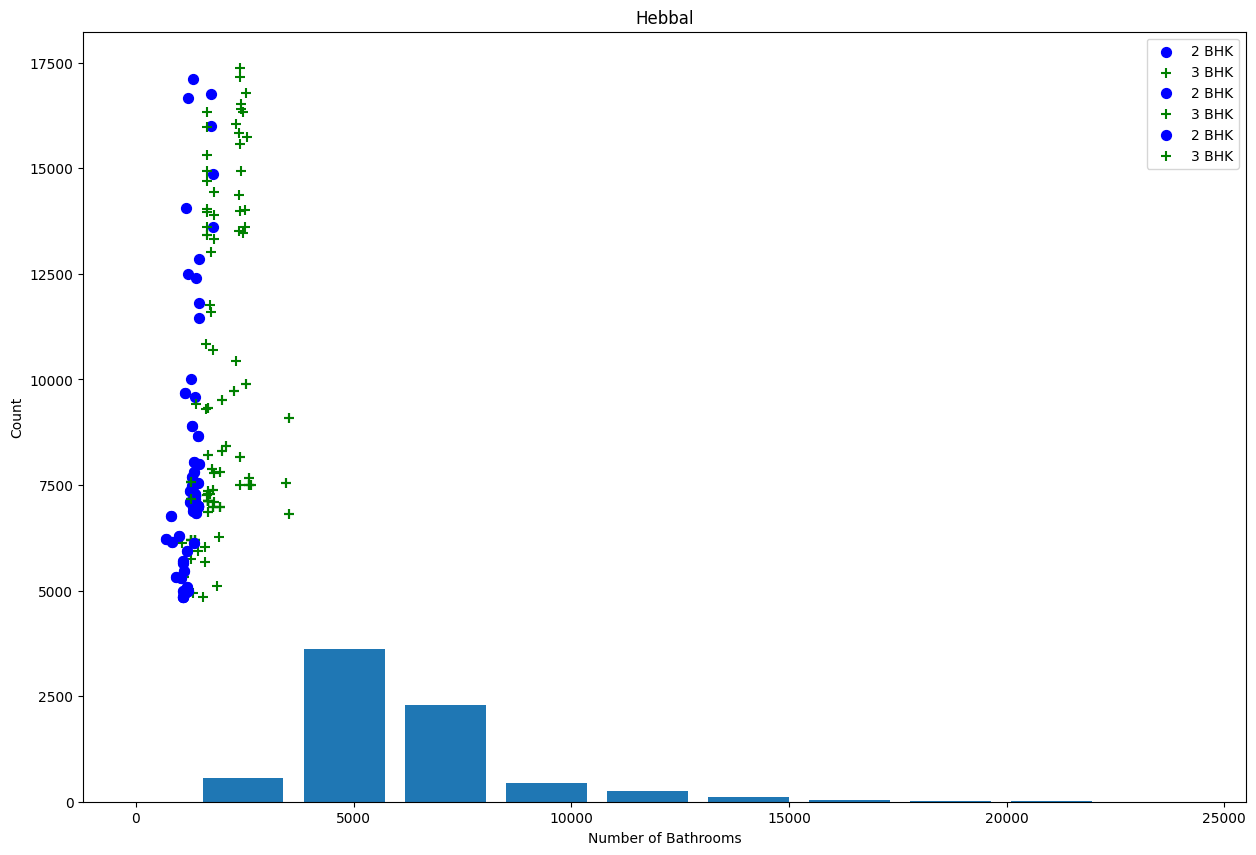

In [2]:
!pip install pandas numpy matplotlib
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import matplotlib

# Set default figure size
matplotlib.rcParams["figure.figsize"] = (20, 10)
df=pd.read_csv('Bengalaru_House_data.csv')
df
df.shape
df.groupby('area_type')['area_type'].agg('count')
df1=df.drop(['area_type','society','balcony','availability'],axis='columns')
df1
df1.isnull().sum()
df2=df1.dropna()
df2.isnull().sum()
df2.shape
df2['size'].unique()
df2['bhk']=df2['size'].apply(lambda x: int(x.split(' ')[0]))
df2
df2['bhk'].unique()
df2[df2.bhk>20]
df2.total_sqft.unique()
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True
df2[~df2['total_sqft'].apply(is_float)]
def convert_sqft_to_num(x):
    tokens=x.split('-')
    if(len(tokens)==2):
        return (float(tokens[0])+float(tokens[1]))/2
    try:
        return float(x)
    except:
        return None
convert_sqft_to_num('2166')
convert_sqft_to_num('2100-2850')
convert_sqft_to_num('34.46 Sq. Meter')
df3=df2.copy()
df3['total_sqft']=df3['total_sqft'].apply(convert_sqft_to_num)
df3
df3.loc[30]
df3
df4=df3.copy()
df4['price_per_sqft']=df4['price']*100000/df4['total_sqft']
df4
len(df4.location.unique())
df4.location=df4.location.apply(lambda x: x.strip())
location_stats=df4.groupby('location')['location'].agg('count').sort_values(ascending=False)
location_stats
len(df4.location.unique())

location_stats_less_than_10 = location_stats[location_stats < 10].index

df4.location=df4.location.apply(lambda x:'other' if x in location_stats_less_than_10 else x)
len(df4.location.unique())
df4
df4[df4.total_sqft/df4.bhk<300].head()
df4.shape
df5=df4[~(df4.total_sqft/df4.bhk<300)]
df5.shape
df5.price_per_sqft.describe()
def remove_pps_outliers(df):
    df_out=pd.DataFrame()
    for key,subdf in df.groupby('location'):
        m=np.mean(subdf.price_per_sqft)
        st=np.std(subdf.price_per_sqft)
        reduced_df=subdf[(subdf.price_per_sqft>(m-st)) & (subdf.price_per_sqft<=(m+st))]
        df_out=pd.concat([df_out,reduced_df],ignore_index=True)
    return df_out

df6=remove_pps_outliers(df5)
df6.shape
def plot_scatter_chart(df,location):
    bhk2=df[(df.location==location) & (df.bhk==2)]
    bhk3=df[(df.location==location) & (df.bhk==3)]
    matplotlib.rcParams['figure.figsize']=(15,10)
    plt.scatter(bhk2.total_sqft,bhk2.price_per_sqft,color='blue',label='2 BHK',s=50)
    plt.scatter(bhk3.total_sqft,bhk3.price_per_sqft,marker='+',color='green',label='3 BHK',s=50)
    plt.xlabel("Total Square feet Area")
    plt.ylabel("Price Per Square feet")
    plt.title(location)
    plt.legend()

plot_scatter_chart(df6,'Rajaji Nagar')
plot_scatter_chart(df6,'Hebbal')
def remove_bhk_outliers(df):
    exclude_indices = np.array([])
    for location, location_df in df.groupby('location'):
        bhk_stats = {}
        for bhk, bhk_df in location_df.groupby('bhk'):
            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }
        for bhk, bhk_df in location_df.groupby('bhk'):
            stats = bhk_stats.get(bhk-1)
            if stats and stats['count'] > 5:
                exclude_indices = np.append(
                    exclude_indices,
                    bhk_df[bhk_df.price_per_sqft < stats['mean']].index.values
                )
    return df.drop(exclude_indices, axis='index')
df7=remove_bhk_outliers(df6)
df7.shape
plot_scatter_chart(df7,'Hebbal')
import matplotlib
matplotlib.rcParams["figure.figsize"]=(20,10)
plt.hist(df7.price_per_sqft,rwidth=0.8)
plt.xlabel("Price Per Square Feet")
plt.ylabel("Count")
df7.bath.unique()
df7[df7.bath>10]
plt.hist(df7.bath,rwidth=0.8)
plt.xlabel("Number of Bathrooms")
plt.ylabel("Count")
df7[df7.bath>df7.bhk+2]
df8=df7[df7.bath<df7.bhk+2]
df8.shape
df9=df8.drop(['size','price_per_sqft'],axis='columns')
df9.head()
dummies=pd.get_dummies(df9.location)
dummies
df10=pd.concat([df9,dummies.drop('other',axis='columns')],axis='columns')
df10
df11=df10.drop('location',axis='columns')
df11.head()
df11.shape
X=df11.drop('price',axis='columns')
X.head()
y=df11.price
y.head()
!pip install scikit-learn
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)
from sklearn.linear_model import LinearRegression
lr_clf=LinearRegression()
lr_clf.fit(X_train,y_train)
lr_clf.score(X_test,y_test)
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv=ShuffleSplit(n_splits=5,test_size=0.2,random_state=0)
cross_val_score(LinearRegression(),X,y,cv=cv)

from sklearn.model_selection import GridSearchCV, ShuffleSplit
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
import pandas as pd

def find_best_model_using_gridsearchcv(X, y):
    algos = {
        'linear_regression': {
            'model': LinearRegression(),
            'params': {
                'fit_intercept': [True, False]
            }
        },
        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [1, 2],
                'selection': ['random', 'cyclic']
            }
        },
        'decision_tree': {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion': ['squared_error', 'friedman_mse'],
                'splitter': ['best', 'random']
            }
        }
    }
    
    scores = []
    cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
    
    for algo_name, config in algos.items():
        gs = GridSearchCV(config['model'], config['params'], cv=cv, return_train_score=False)
        gs.fit(X, y)
        scores.append({
            'model': algo_name,
            'best_score': gs.best_score_,
            'best_params': gs.best_params_
        })
    
    return pd.DataFrame(scores, columns=['model', 'best_score', 'best_params'])
find_best_model_using_gridsearchcv(X,y)
X.columns
np.where(X.columns=='2nd Phase Judicial Layout')[0][0]
def predict_price(location,sqft,bath,bhk):
    loc_index=np.where(X.columns==location)[0][0]
    x=np.zeros(len(X.columns))
    x[0]=sqft
    x[1]=bath
    x[2]=bhk
    if loc_index>=0:
        x[loc_index]=1
    return lr_clf.predict([x])[0]
predict_price('1st Phase JP Nagar',1000,2,2)
predict_price('1st Phase JP Nagar',1000,3,3)
predict_price('Indira Nagar',1000,2,2)
predict_price('Indira Nagar',1000,3,3)
import pickle
with open('banglore_home_prices_model.pickle','wb') as f:
    pickle.dump(lr_clf,f)

import json
columns={
    'data_columns':[col.lower() for col in X.columns]

}
with open("columns.json","w") as f:
    f.write(json.dumps(columns))



#this is my first.ipynb and i m buildinf real estate price prediction project

